# **Image Restoration & Reconstruction**

Image Restoration and Image Reconstruction are fundamental processes in digital image processing aimed at recovering or enhancing images that have been degraded or are partially available. These techniques are critical in fields like medical imaging, photography, and remote sensing.

* Image Restoration focuses on reversing the degradation of an image to recover its original quality. Degradation can occur due to factors like noise (e.g., Gaussian or salt-and-pepper), blur (e.g., from motion or out-of-focus lenses), or other distortions. The process starts with a mathematical model, typically $ g(x,y) = h(x,y) * f(x,y) + n(x,y) $, where $ g $ is the degraded image, $ h $ is the degradation function (e.g., point spread function), $ f $ is the original image, and $ n $ is noise. Techniques such as spatial filtering (e.g., mean or median filters), frequency-domain filtering (e.g., for periodic noise), and advanced methods like Wiener filtering are used to restore the image by mitigating these effects.

* Image Reconstruction involves creating a complete image from partial data, such as projections or slices. This is common in applications like computed tomography (CT) scans, where X-ray projections are combined to form a 2D or 3D image. The process often relies on the Radon transform to generate a sinogram from projections, followed by filtered backprojection to reconstruct the image. Unlike restoration, reconstruction deals with incomplete data rather than degraded versions of a full image

In [3]:
import numpy as np
import cv2
import matplotlib. pyplot as plt
from skimage. transform import radon, iradon

%matplotlib inline

## **A Model of the Image Degradation/Restoration Process**

From a research perspective, the "A Model of the Image Degradation/Restoration Process" serves as a foundational framework for understanding and addressing the challenges of recovering degraded images. This model is critical for developing and evaluating restoration algorithms, making it a cornerstone for advancing image processing techniques.

Theoretical Foundation
The degradation/restoration process is mathematically modeled as:
$ g(x, y) = h(x, y) * f(x, y) + n(x, y) $

**Components**:

* $ f(x, y) $: The original, undistorted image, which researchers aim to recover.
* $ h(x, y) $: The degradation function (e.g., point spread function or PSF), representing the blurring or distortion mechanism (linear and position-invariant in many cases).
* $ n(x, y) $: Additive noise, which introduces random perturbations (e.g., Gaussian, salt-and-pepper).
* $ g(x, y) $: The observed degraded image, which is the input to restoration algorithms.
* $ * $: Convolution operator, indicating that degradation is a linear transformation of the original image filtered by $ h $, combined with noise.



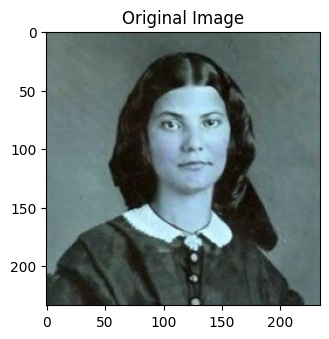

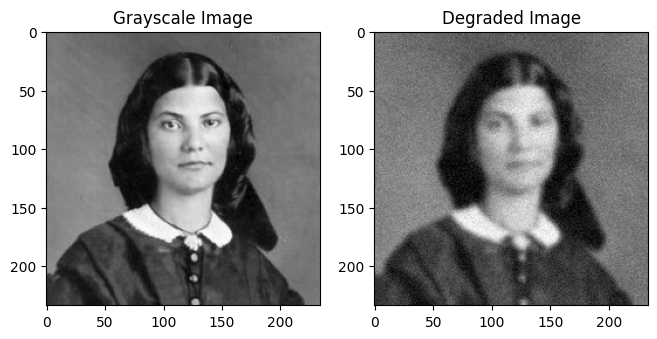

In [ ]:

# Simulate degradation model: g = h * f + n
def degrade_image (original, blur_sigma=2, noise_std=10) :
# Apply Gaussian blur as degradation function h
    blurred = cv2. GaussianBlur (original, (9, 9), blur_sigma)
    # Add Gaussian noise n
    noise = np. random. normal (0, noise_std, original . shape)
    degraded = np. clip (blurred + noise, 0, 255) . astype (np.uint8)
    return degraded

# Test case
img = cv2. imread ('k.jpg')
image = cv2. imread ('k.jpg', cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide'k.jpg' . ")
degraded = degrade_image (image)

cv2.imwrite('Degraded/original_image.jpg', image)
cv2.imwrite('Degraded/degraded_image.jpg', degraded)

plt.figure(figsize=(12, 4))
plt.subplot(131); plt.imshow(img); plt.title('Original Image');

plt.figure(figsize=(12, 4))
plt.subplot(131); plt.imshow(image, cmap='gray'); plt.title('Grayscale Image');
plt.subplot(132); plt.imshow (degraded, cmap='gray' ); plt.title ('Degraded Image');

## **Noise Models**

The section on "Noise Models" is a critical component of image restoration research, as noise significantly impacts image quality and complicates the recovery process. From a research perspective, understanding noise models involves characterizing their statistical properties, developing methods to mitigate their effects, and exploring their implications for advanced restoration techniques.

Noise in digital images is typically modeled as an additive component $ n(x, y) $ in the degradation equation $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $, where $ g $ is the degraded image, $ h $ is the degradation function, and $ f $ is the original image. The nature of $ n $ varies depending on the imaging system and environmental conditions, and research focuses on defining and analyzing these models to inform restoration strategies.

**Common Noise Models**:

* Gaussian Noise: Arises from thermal or electronic sources, modeled as a Gaussian distribution with zero mean and variance $ \sigma^2 $. Its probability density function is $ p(n) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{n^2}{2\sigma^2}} $.

* Salt-and-Pepper Noise: Results from bit errors or dead pixels, appearing as random white (255) or black (0) pixels with a uniform probability over a small fraction of the image.

* Periodic Noise: Caused by electrical interference or mechanical vibrations, manifesting as sinusoidal patterns with specific frequencies.

* Poisson Noise: Common in low-light imaging (e.g., photon counting), where noise variance is proportional to the signal intensity.



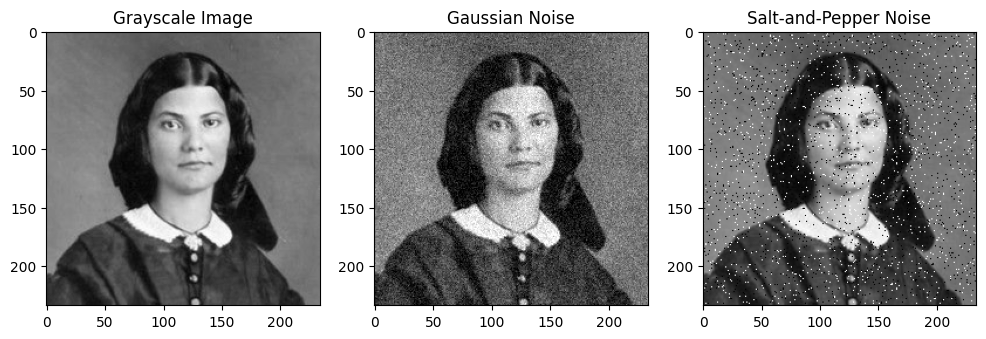

In [ ]:
# Add different noise models
def add_noise (image, noise_type='gaussian', noise_std=10, sp_ratio=0.05) :
    if noise_type == 'gaussian' :
        noise = np. random. normal (0, noise_std, image . shape)
        noisy = image + noise
    elif noise_type == 'salt_pepper' :
        noisy = image . copy ()
        num_salt = int (np.ceil(sp_ratio * image. size * 0.5))
        coords = [np.random. randint (0, i - 1, num_salt) for i in
        image . shape]
        noisy [coords [0], coords [1]] = 255
        num_pepper = int (np. ceil (sp_ratio * image.size * 0.5))
        coords = [np. random. randint (0, i - 1, num_pepper) for i
        in image . shape]
        noisy [coords [0], coords [1]] = 0
    return np. clip (noisy, 0, 255) . astype (np. uint8)

# Test case
image = cv2. imread ('k.jpg', cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide'k.jpg' . ")
gaussian_noisy = add_noise (image, 'gaussian', noise_std=20)
sp_noisy = add_noise (image, 'salt_pepper' , sp_ratio=0.05)

cv2.imwrite('Noisy/original_image.jpg', image)
cv2.imwrite('Noisy/gaussian_noisy.jpg', gaussian_noisy)
cv2.imwrite('Noisy/sp_noisy.png', sp_noisy)

plt.figure(figsize=(12, 4))
plt.subplot(131);plt.imshow(image, cmap='gray');plt.title('Grayscale Image');
plt.subplot(132);plt.imshow(gaussian_noisy, cmap='gray');plt.title('Gaussian Noise');
plt.subplot(133);plt.imshow(sp_noisy, cmap='gray');plt.title('Salt-and-Pepper Noise');

## **Restoration in the Presence of Noise OnlySpatial Filtering**

The section "Restoration in the Presence of Noise Only—Spatial Filtering" ) focuses on techniques to restore images degraded primarily by noise, without significant blur or other complex degradations. From a research perspective, this topic is pivotal for developing robust noise reduction methods, understanding their limitations, and advancing image processing algorithms.

Spatial filtering operates directly on the image pixel values in the spatial domain, aiming to suppress noise while preserving important image features (e.g., edges, textures). The degradation model simplifies to $ g(x, y) \approx f(x, y) + n(x, y) $ when the degradation function $ h(x, y) $ is negligible or identity (no blur). The goal is to estimate $ f(x, y) $ by applying a filter kernel over a local neighborhood of pixels.

**Common Spatial Filters**:

* Mean Filter: Replaces each pixel with the average of its neighbors within a window (e.g., 3x3 or 5x5). Mathematically, for a pixel at $(x, y)$, the output is:
$ f'(x, y) = \frac{1}{M} \sum_{(i, j) \in W} g(x+i, y+j) $
where $ W $ is the window and $ M $ is the number of pixels in $ W $.

* Median Filter: Replaces each pixel with the median value of its neighbors, effective for impulsive noise (e.g., salt-and-pepper).

* Adaptive Filters: Adjust the filter based on local statistics (e.g., variance), balancing noise reduction and detail preservation.

Text(0.5, 1.0, 'Median Filter')

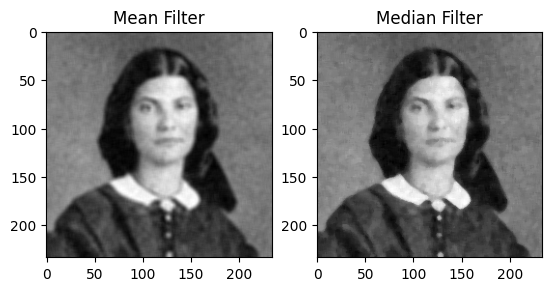

In [ ]:
# Apply spatial filtering
def spatial_filtering(image):
    mean_filtered = cv2.blur(image, (5, 5))
    median_filtered = cv2.medianBlur(image, 5)
    return mean_filtered, median_filtered

# Test case
image = cv2.imread('k.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError("Image not found. Please provide 'lena.png'.")

# Assuming add_noise is defined in previous cells
noisy = add_noise(image, 'gaussian', noise_std=20)
mean_filtered, median_filtered = spatial_filtering(noisy)

cv2.imwrite('Filtered/mean_filtered.jpg', mean_filtered)
cv2.imwrite('Filtered/median_filtered.jpg', median_filtered)

plt.subplot(121)
plt.imshow(mean_filtered, cmap='gray')
plt.title('Mean Filter')

plt.subplot(122)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filter')

## **Periodic Noise Reduction Using Frequency Domain Filtering**

The section "Periodic Noise Reduction Using Frequency Domain Filtering" addresses the removal of periodic noise—such as sinusoidal patterns caused by electrical interference or mechanical vibrations—from degraded images. From a research perspective, this technique is significant for its reliance on frequency-domain analysis, offering a targeted approach to noise suppression that complements spatial methods.


Periodic noise manifests as repetitive patterns in the image, often due to interference at specific frequencies. In the frequency domain, this noise appears as distinct peaks in the Fourier spectrum, making it amenable to targeted removal. The process leverages the convolution theorem, where the degradation model $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $ is transformed into the frequency domain as:
$ G(u, v) = H(u, v) F(u, v) + N(u, v) $

**Components**:

* $ G(u, v) $: Fourier transform of the degraded image $ g(x, y) $.
* $ H(u, v) $: Fourier transform of the degradation function $ h(x, y) $.
* $ F(u, v) $: Fourier transform of the original image $ f(x, y) $.
* $ N(u, v) $: Fourier transform of the noise $ n(x, y) $, which shows periodic peaks for periodic noise.


Frequency Domain Filtering: The approach involves:

Computing the 2D Fast Fourier Transform (FFT) of the image to obtain $ G(u, v) $.
Identifying and suppressing the frequency components corresponding to periodic noise using a filter (e.g., notch filter).
Applying the inverse FFT to reconstruct the image.


Notch Filter: A spatial filter in the frequency domain that zeros out specific frequency bands around the noise peaks, preserving the rest of the spectrum.



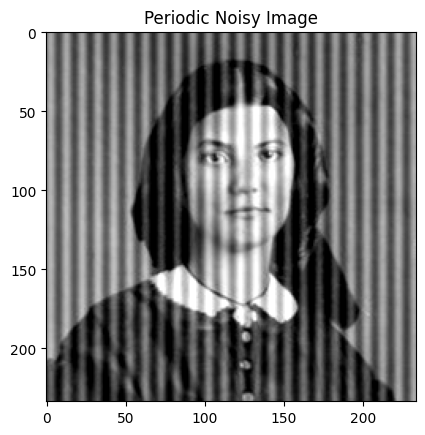

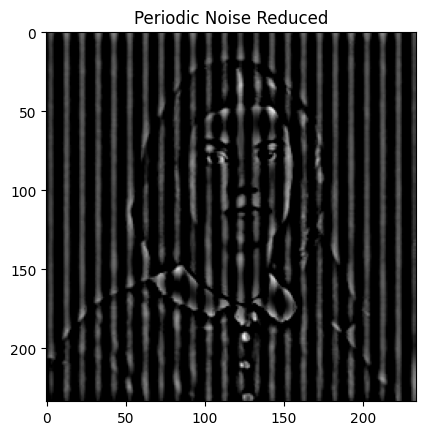

In [ ]:
# Add periodic noise and reduce it
def add_periodic_noise (image, amplitude=50, freq=0.1) :
    x, y = np. meshgrid (np. arange ( image . shape [1]) ,
        np. arange ( image . shape [0] ) )
    noise = amplitude * np.sin(2 * np.pi * freq * x)
    return np. clip (image + noise, 0, 255) . astype (np. uint8)

def periodic_noise_reduction (image):
    f = np. fft . fft2(image)
    fshift = np. fft . fftshift (f)
    rows, cols = image . shape
    crow, ccol = rows // 2, cols // 2
    notch = np. ones ((rows, cols) )
    notch [crow-10:crow+10, ccol-10: ccol+10] = 0
    fshift_filtered = fshift * notch
    f_ishift = np. fft. ifftshift (fshift_filtered)
    img_back = np.fft. ifft2(f_ishift) .real
    return np. clip (img_back, 0, 255) . astype (np. uint8)

# Test case
image = cv2. imread ('k.jpg', cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide 'k.jpg' . ")
periodic_noisy = add_periodic_noise (image)
filtered = periodic_noise_reduction (periodic_noisy)

cv2.imwrite('Periodic_Noise/periodic_noisy.jpg', periodic_noisy)
cv2.imwrite('Periodic_Noise/filtered.jpg', filtered)

plt.imshow(periodic_noisy, cmap='gray')
plt.title('Periodic Noisy Image')
plt.show()

plt. imshow(filtered, cmap='gray')
plt. title ('Periodic Noise Reduced')
plt . show ()

## **Linear, Position-Invariant Degradations** 

The section "Linear, Position-Invariant Degradations" explores a specific class of image degradation where the distortion is both linear and consistent across the image. From a research perspective, this topic is foundational for developing restoration algorithms, understanding degradation mechanisms, and advancing image processing techniques.

Linear, position-invariant (LPI) degradations assume that the degradation process can be modeled as a linear operation applied uniformly across all spatial locations in the image. This is represented in the degradation model $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $, where:

* $ f(x, y) $: The original image.
* $ h(x, y) $: The point spread function (PSF), a linear, space-invariant kernel that describes the degradation (e.g., blur).
* $ * $: Convolution operator, indicating that the degradation is a weighted sum of the original image over a local neighborhood, with weights defined by $ h $.
* $ n(x, y) $: Additive noise, which may or may not be present.
* $ g(x, y) $: The degraded image.

`Linearity`: The response to a sum of inputs is the sum of the individual responses, allowing the use of superposition principles.

`Position-Invariance`: The PSF $ h(x, y) $ is the same for all $(x, y)$, meaning the degradation effect does not vary with location (e.g., uniform blur across the image).
Frequency Domain Representation: Due to the convolution property, the degradation transforms to a multiplication in the frequency domain: $ G(u, v) = H(u, v) F(u, v) + N(u, v) $, where $ H(u, v) $ is the optical transfer function (OTF), the Fourier transform of $ h(x, y) $. This facilitates analysis and restoration using Fourier transforms.



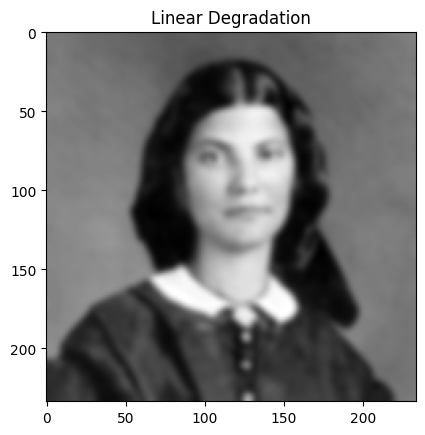

In [ ]:
# Simulate linear, position-invariant degradation
def apply_degradation (image, psf_size=9, sigma=2) :
    psf = cv2. getGaussianKernel (psf_size, sigma)
    psf = np. outer (psf, psf)
    degraded = cv2. filter2D (image, -1, psf)
    return np. clip(degraded, 0, 255) . astype (np. uint8)

# Test case
image = cv2. imread ('k.jpg', cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide'k.jpg' . ")
degraded = apply_degradation (image)

cv2.imwrite('L_PI_Degraded/original_image.jpg', image)
cv2.imwrite('L_PI_Degraded/degraded_image.jpg', degraded)


plt . imshow (degraded, cmap='gray')
plt. title ('Linear Degradation')
plt . show ()

## **Estimating the Degradation Function**

The section "Estimating the Degradation Function" in the image degradation model $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $, where $ g $ is the degraded image, $ f $ is the original image, and $ n $ is additive noise. From a research perspective, this topic is pivotal for enabling effective image restoration, especially when the degradation function is unknown or partially known.


The degradation function $ h(x, y) $, often represented as a point spread function (PSF) in the case of linear, position-invariant degradations, describes how the image is blurred or distorted. In the frequency domain, $ H(u, v) $ (the optical transfer function, OTF) modulates the image spectrum. Estimating $ h(x, y) $ is essential for inverse problems in restoration, as the accuracy of $ h $ directly impacts the quality of the recovered $ f(x, y) $.

Estimation Approaches:

Known PSF Approximation: If the degradation source (e.g., defocus, motion) is known, $ h(x, y) $ can be modeled (e.g., Gaussian for out-of-focus blur).
Image-Based Estimation: Analyze the degraded image $ g(x, y) $ and, if available, an undistorted reference image or region to infer $ h(x, y) $.
Blind Estimation: Infer $ h(x, y) $ without prior knowledge, often using iterative or statistical methods.

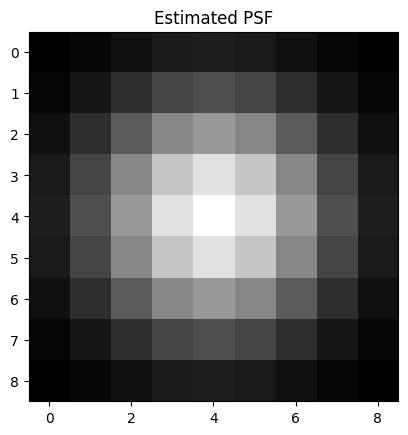

In [52]:
# Simplified estimation (assuming known blur)
def estimate_degradation (image, degraded) :
    psf_size = 9
    sigma = 2
    psf = cv2.getGaussianKernel (psf_size, sigma)
    psf = np. outer (psf, psf)
    return psf

# Test case
image = cv2. imread ('k.jpg', cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide'lena. png ' . ")
degraded = apply_degradation (image) # Assuming apply_degradation from previous section
estimated_psf = estimate_degradation (image, degraded)

cv2.imwrite('Estimated_PSF/original_image.jpg', image)
cv2.imwrite('Estimated_PSF/degraded_image.jpg', degraded)

plt. imshow (estimated_psf, cmap='gray')
plt . title ('Estimated PSF')
plt . show ()

## **Inverse Filtering**

The section "Inverse Filtering"  introduces a direct method for image restoration based on reversing the degradation process modeled as $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $, where $ g $ is the degraded image, $ h $ is the degradation function (e.g., point spread function), $ f $ is the original image, and $ n $ is additive noise. From a research perspective, inverse filtering is a foundational technique that highlights both the potential and limitations of restoration, driving advancements in more robust methods.

Inverse filtering aims to recover the original image $ f(x, y) $ by undoing the effect of the degradation function $ h(x, y) $. In the frequency domain, using the convolution theorem, the degradation model becomes:

$ G(u, v) = H(u, v) F(u, v) + N(u, v) $

where $ G(u, v) $, $ H(u, v) $, $ F(u, v) $, and $ N(u, v) $ are the Fourier transforms of $ g(x, y) $, $ h(x, y) $, $ f(x, y) $, and $ n(x, y) $, respectively. The inverse filtering approach estimates $ F(u, v) $ as:

$ \hat{F}(u, v) = \frac{G(u, v)}{H(u, v)} $

`Inverse Process`: The degraded image’s Fourier transform $ G(u, v) $ is divided by the degradation function’s Fourier transform $ H(u, v) $ (the optical transfer function, OTF), and the inverse Fourier transform is applied to obtain the restored image $ \hat{f}(x, y) $.

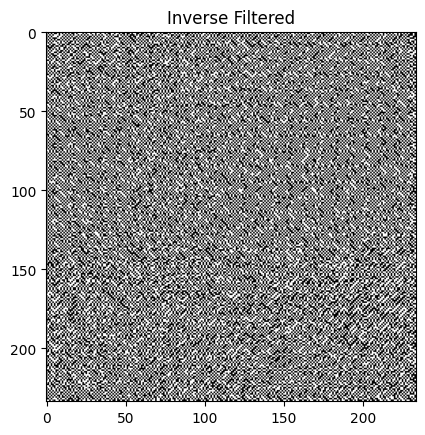

In [53]:
# Inverse filtering
def inverse_filter (degraded, psf) :
    degraded_freq = np.fft.fft2(degraded)
    psf_freq = np. fft. fft2(psf, s=degraded. shape)
    restored_freq = degraded_freq / (psf_freq + 1e-10) # Avoiddivision by zero
    restored = np. fft. ifft2(restored_freq) . real
    return np. clip(restored, 0, 255) . astype (np. uint8)

# Test case
image = cv2. imread ('k.jpg', cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide'k.jpg' . ")
degraded = apply_degradation (image) # Assuming apply_degradation
psf = cv2. getGaussianKernel (9, 2)
psf = np. outer (psf, psf)
restored = inverse_filter (degraded, psf)

cv2.imwrite('Inverse_Filtered/original_image.jpg', image)
cv2.imwrite('Inverse_Filtered/degraded_image.jpg', degraded)

plt . imshow (restored, cmap='gray')
plt. title ('Inverse Filtered')
plt. show ()

## **Minimum Mean Square Error (Wiener) Filtering** 

The section "Minimum Mean Square Error (Wiener) Filtering" presents a sophisticated restoration technique that addresses the limitations of inverse filtering by minimizing the mean square error between the restored and original images. From a research perspective, Wiener filtering is a cornerstone of image restoration, offering a balanced approach to noise suppression and blur removal, and it continues to inspire advancements in the field.


Wiener filtering is designed to restore the original image $ f(x, y) $ from the degraded image $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $, where $ h $ is the degradation function (e.g., point spread function) and $ n $ is additive noise. In the frequency domain, the degradation becomes $ G(u, v) = H(u, v) F(u, v) + N(u, v) $. The goal is to estimate $ \hat{F}(u, v) $ by minimizing the mean square error (MSE) between $ \hat{f}(x, y) $ and $ f(x, y) $, defined as:

$ \text{MSE} = E\left[ |\hat{f}(x, y) - f(x, y)|^2 \right] $

Wiener Filter Formula: The optimal filter in the frequency domain is given by:

$ \hat{F}(u, v) = \frac{H^*(u, v) G(u, v)}{|H(u, v)|^2 + \frac{S_n(u, v)}{S_f(u, v)}} $

* $ H^*(u, v) $: Complex conjugate of $ H(u, v) $, the OTF.
* $ S_n(u, v) $: Power spectral density of the noise $ n(x, y) $.
* $ S_f(u, v) $: Power spectral density of the original image $ f(x, y) $.

The term $ \frac{S_n(u, v)}{S_f(u, v)} $ acts as a regularization parameter, adjusting the filter to balance noise suppression and signal restoration.
Simplified Form: If $ S_n(u, v) $ and $ S_f(u, v) $ are assumed constant or estimated as a ratio $ K $ (noise-to-signal power), the filter simplifies to:

$ \hat{F}(u, v) = \frac{H^*(u, v) G(u, v)}{|H(u, v)|^2 + K} $




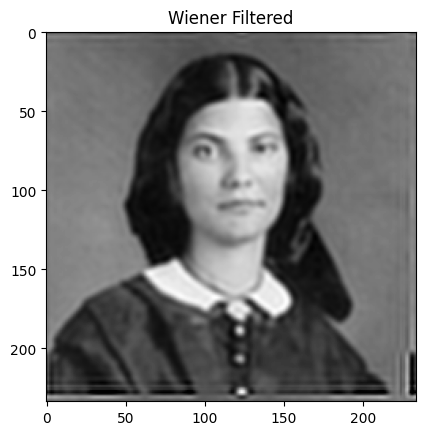

In [54]:
# Wiener filtering
def wiener_filter (degraded, psf, k=0.01) :
    degraded_freq = np.fft.fft2(degraded)
    psf_freq = np. fft. fft2(psf, s=degraded. shape)
    wiener_freq = np. conj (psf_freq) / (np.abs(psf_freq) ** 2 + k)
    restored_freq = degraded_freq * wiener_freq
    restored = np. fft. ifft2(restored_freq) .real
    return np. clip (restored, 0, 255) . astype (np. uint8)

# Test case
image = cv2. imread ('k.jpg', cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide 'k.jpg' . ")
degraded = apply_degradation (image) # Assuming apply_degradation
psf = cv2. getGaussianKernel (9, 2)
psf = np. outer (psf, psf)

cv2.imwrite('Wiener_Filtered/original_image.jpg', image)
cv2.imwrite('Wiener_Filtered/degraded_image.jpg', degraded)


restored = wiener_filter (degraded, psf)
plt. imshow (restored, cmap='gray')
plt. title ('Wiener Filtered')
plt . show ()

## **Constrained Least Squares Filtering**

The section "Constrained Least Squares Filtering" introduces an advanced image restoration technique that builds on the limitations of inverse and Wiener filtering by incorporating smoothness constraints to stabilize the restoration process. From a research perspective, this method is significant for its ability to handle ill-posed problems in image degradation, offering a framework for further innovation in restoration algorithms.


Constrained Least Squares (CLS) filtering aims to restore the original image $ f(x, y) $ from the degraded image $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $, where $ h $ is the degradation function (e.g., point spread function), and $ n $ is additive noise. Unlike inverse filtering, which amplifies noise, or Wiener filtering, which relies on noise-to-signal power ratios, CLS minimizes the squared difference between the observed and restored images while enforcing a smoothness constraint. In the frequency domain, the restoration problem is formulated as:

$ \hat{F}(u, v) = \arg\min \left[ \| G(u, v) - H(u, v) F(u, v) \|^2 + \gamma \| P(u, v) F(u, v) \|^2 \right] $

**Components**:

* $ G(u, v) $: Fourier transform of the degraded image.
* $ H(u, v) $: Fourier transform of the degradation function (OTF).
* $ F(u, v) $: Fourier transform of the estimated original image.
* $ P(u, v) $: Fourier transform of a high-pass filter (e.g., Laplacian operator), enforcing smoothness by penalizing high-frequency components.
* $ \gamma $: Regularization parameter controlling the trade-off between data fidelity and smoothness.


Solution: The optimal $ \hat{F}(u, v) $ is derived as:

$ \hat{F}(u, v) = \frac{H^*(u, v) G(u, v)}{|H(u, v)|^2 + \gamma |P(u, v)|^2} $

where $ H^*(u, v) $ is the complex conjugate of $ H(u, v) $. This resembles Wiener filtering but uses $ \gamma |P(u, v)|^2 $ as a frequency-dependent regularization term.


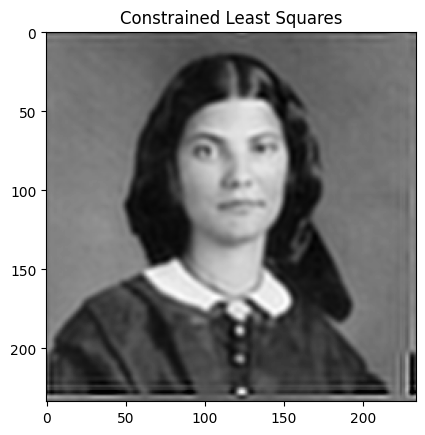

In [55]:
# Simplified constrained least squares (basic regularization)
def constrained_least_squares(degraded, psf, lambda_ = 0.01) :
    degraded_freq = np. fft.fft2(degraded)
    psf_freq = np.fft.fft2(psf, s=degraded. shape)
    # Simple regularization (actual implementation requires Laplacian constraint)
    restored_freq = degraded_freq * np. conj (psf_freq) / (np. abs (psf_freq) ** 2 + lambda_)
    restored = np. fft. ifft2(restored_freq).real
    return np. clip(restored, 0, 255) . astype (np. uint8)

# Test case
image = cv2. imread ('k.jpg' , cv2. IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError ("Image not found. Please provide'k.jpg' . ")
degraded = apply_degradation (image) # Assuming apply_degradation
psf = cv2. getGaussianKernel (9, 2)
psf = np. outer (psf, psf)
restored = constrained_least_squares (degraded, psf)

cv2.imwrite('Constrained_Least_Squares/original_image.jpg', image)
cv2.imwrite('Constrained_Least_Squares/degraded_image.jpg', degraded)

plt . imshow (restored, cmap='gray')
plt . title ('Constrained Least Squares')
plt . show ()

## **Geometric Mean Filter**

The section "Geometric Mean Filter"  introduces a hybrid restoration technique that combines elements of inverse and Wiener filtering to address image degradation modeled as $ g(x, y) = h(x, y) * f(x, y) + n(x, y) $, where $ g $ is the degraded image, $ h $ is the degradation function (e.g., point spread function), $ f $ is the original image, and $ n $ is additive noise. From a research perspective, this filter is significant for its unique approach to balancing noise suppression and signal restoration, offering a niche area for further exploration and improvement.


The Geometric Mean Filter (GMF) restores the image by taking the geometric mean of the inverse filter and a noise-suppressing term, aiming to mitigate the noise amplification issues of inverse filtering while preserving more image details than Wiener filtering. In the frequency domain, the degradation is represented as $ G(u, v) = H(u, v) F(u, v) + N(u, v) $. The GMF estimates $ \hat{F}(u, v) $ as:
$ \hat{F}(u, v) = \left[ \frac{G(u, v)}{H(u, v)} \cdot \frac{H^*(u, v) G(u, v)}{|H(u, v)|^2 + K} \right]^{1/2} $

**Components**:

* $ G(u, v) $: Fourier transform of the degraded image.
* $ H(u, v) $: Fourier transform of the degradation function (OTF).
* $ H^*(u, v) $: Complex conjugate of $ H(u, v) $.
* $ K $: A regularization parameter analogous to the noise-to-signal power ratio in Wiener filtering.

The geometric mean combines the inverse filter $ \frac{G(u, v)}{H(u, v)} $ with a Wiener-like term $ \frac{H^*(u, v) G(u, v)}{|H(u, v)|^2 + K} $, raised to the power of $ 1/2 $.


Simplified Form: The geometric_mean_filter function from the previous implementation approximates this as:

$ \hat{F}(u, v) = G(u, v) \cdot \left[ \frac{H^*(u, v)}{|H(u, v)|^2 + K} \right]^{1/2} $

adjusting for practical computation and avoiding direct division by $ H(u, v) $ alone to reduce noise amplification.



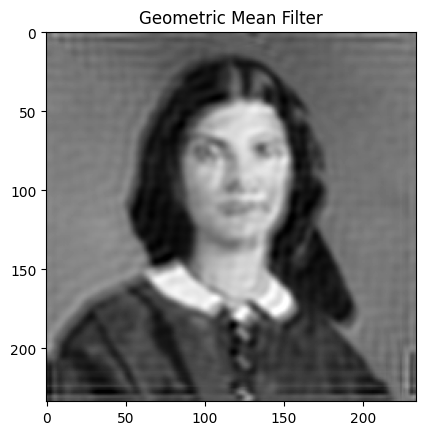

In [56]:
# Geometric mean filter (simplified)
def geometric_mean_filter(degraded, psf, k=0.01):
    degraded_freq = np.fft.fft2(degraded)
    psf_freq = np.fft.fft2(psf, s=degraded.shape)
    geo_freq = (np.conj(psf_freq) / (np.abs(psf_freq)**2 + k)) ** 0.5  # Geometric mean approach
    restored_freq = degraded_freq * geo_freq
    restored = np.fft.ifft2(restored_freq).real

    return np.clip(restored, 0, 255).astype(np.uint8)

# Test case
image = cv2.imread('k.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError("Image not found. Please provide 'lena.png'.")

degraded = apply_degradation(image)  # Assuming apply_degradation is defined
psf = cv2.getGaussianKernel(9, 2)
psf = np.outer(psf, psf)
restored = geometric_mean_filter(degraded, psf)

cv2.imwrite('Geometric_Mean_Filter/original_image.jpg', image)
cv2.imwrite('Geometric_Mean_Filter/degraded_image.jpg', degraded)

plt.imshow(restored, cmap='gray')
plt.title('Geometric Mean Filter')
plt.show()


## **Image Reconstruction from Projections**

The section "Image Reconstruction from Projections" focuses on the process of reconstructing a two-dimensional (2D) image from a series of one-dimensional (1D) projection data, a technique fundamental to applications like medical imaging (e.g., computed tomography or CT) and non-destructive testing. From a research perspective, this topic is a critical area of study due to its complexity, real-world impact, and ongoing advancements in computational methods. 

Image reconstruction from projections involves recovering a 2D image $ f(x, y) $ from a set of 1D projections, which are integrals of the image along various angles. This is mathematically described using the Radon Transform, defined as:

$ P_\theta(t) = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x, y) \delta(x \cos\theta + y \sin\theta - t) \, dx \, dy $

**Components**:

* $ P_\theta(t) $: Projection data at angle $ \theta $ and distance $ t $ from the origin.
* $ \delta $: Dirac delta function, representing the line integral along the projection path.
The set of all $ P_\theta(t) $ for different $ \theta $ (e.g., 0° to 180°) forms a sinogram, a 2D representation of the projection data.


Reconstruction Method: The inverse Radon transform is used to reconstruct $ f(x, y) $. A common approach is Filtered Backprojection (FBP), which involves:

Filtering each projection $ P_\theta(t) $ with a ramp filter in the frequency domain to compensate for the blurring effect of backprojection.
Backprojecting the filtered projections over all angles to form the image.


Frequency Domain Insight: The Fourier Slice Theorem states that the 1D Fourier transform of a projection $ P_\theta(t) $ corresponds to a slice of the 2D Fourier transform of $ f(x, y) $ at angle $ \theta $. Reconstruction assembles these slices to recover the full spectrum.


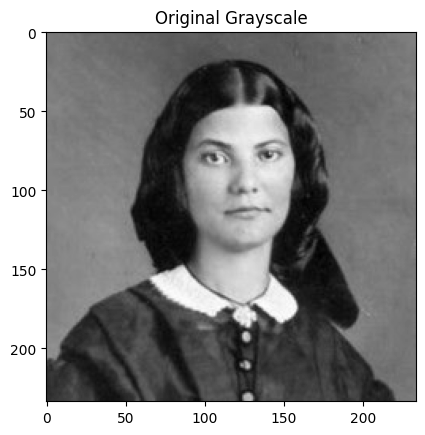

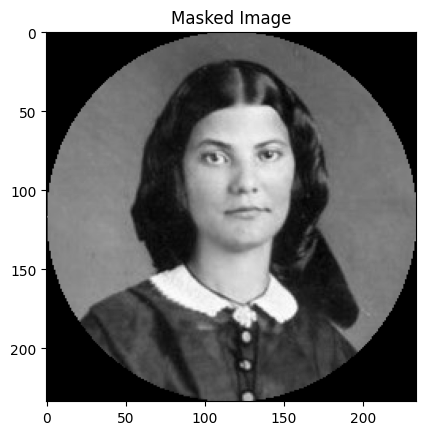

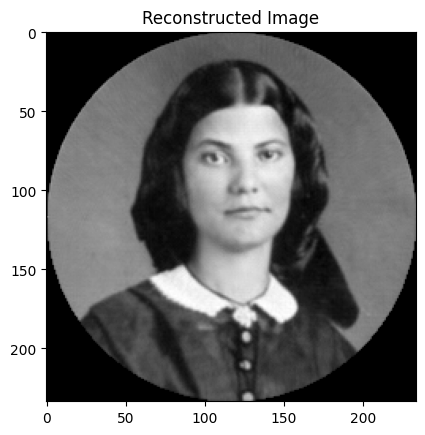

In [57]:
from skimage. transform import radon, iradon
import cv2
import matplotlib. pyplot as plt

# Image reconstruction from projections
def reconstruct_image (image) :
    theta = np. linspace (0., 180., 180, endpoint=False)
    sinogram = radon (image, theta=theta)
    reconstructed = iradon (sinogram, theta=theta,
    filter_name='ramp')
    return np. clip (reconstructed, 0, 255) . astype (np. uint8)

def mask_circle(img):
    h, w = img.shape
    center = (w // 2, h // 2)
    radius = min(center)
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
    mask = dist <= radius
    masked = np.zeros_like(img)
    masked[mask] = img[mask]
    return masked

# Test case
img = cv2.imread('k.jpg')
if img is None:
    raise FileNotFoundError("Image not found. Please provide 'k.jpg'.")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imwrite('Radon/original_image.jpg', gray)
plt.imshow(gray, cmap='gray'); plt.title('Original Grayscale'); plt.show()

masked = mask_circle(gray)
cv2.imwrite('Radon/masked_image.jpg', masked)
plt.imshow(masked, cmap='gray'); plt.title('Masked Image'); plt.show()

# Convert to float for Radon transform
masked_float = masked.astype(np.float32)
reconstructed = reconstruct_image(masked_float)
cv2.imwrite('Radon/reconstructed_image.jpg', reconstructed)
plt.imshow(reconstructed, cmap='gray'); plt.title('Reconstructed Image'); plt.show()

 References

 
 [1] R. C. Gonzalez and R. E. Woods, Digital Image Processing, 4th ed. Pearson, 2018,
 pp. 317368.

 [2] Harris, C.R., et al. "Array programming with NumPy." Nature, vol. 585, no. 7825,
 2020, pp. 357362. https://numpy.org

 [3] Bradski, G. "The OpenCV Library." Dr. Dobb’s Journal of Software Tools, 2000.
 https://opencv.org

 [4] van der Walt, S., et al. "scikit-image: Image processing in Python." PeerJ, vol. 2,
 2014, e453. https://scikit-image.org

 [5] Hunter, J.D. "Matplotlib: A 2D graphics environment." Computing in Science &
 Engineering, vol. 9, no. 3, 2007, pp. 9095. https://matplotlib.org